# Experiment 3
## Tokenization and Part of Speech (POS) Tagging on Customer Reviews

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Natural Language Processing Lab

### Aim
To collect a dataset of customer reviews from an e-commerce dataset and write a python program which performs tokenization and Part of Speech tagging on the reviews.

The following are to be performed :
1. Load at least 5 different customer reviews from a CSV file.
2. Clean and normalize the review text.
3. Tokenize the reviews into words.
4. Assign POS tags to each word using an NLP library.
5. Display the tagged words in the format `Product/NN is/VBZ excellent/JJ`.
6. Identify and display the number of nouns, verbs, adjectives, adverbs and other POS categories.

### Theory
**Part of Speech tagging** means giving a grammatical label to every word of a sentence, like noun, verb, adjective and so on. The same word can have a different tag in a different sentence, for example in "the *charge* is fast" the word charge is a noun but in "I *charge* my phone daily" it is a verb. So the tagger cannot work with a dictionary only, it has to look at the neighbouring words also.

NLTK uses the **Penn Treebank tagset** which has around 36 tags. The ones which come most in reviews are

| Tag | Meaning | Example |
|---|---|---|
| NN, NNS | noun singular, plural | battery, shoes |
| NNP | proper noun | Bluetooth |
| VB, VBZ, VBD, VBG | verb in its different forms | work, works, worked, working |
| JJ, JJR, JJS | adjective, comparative, superlative | good, better, best |
| RB | adverb | quickly |
| DT | determiner | the, a |
| IN | preposition | in, after |
| PRP | pronoun | my, I |
| CC | conjunction | and, but |

The tag of a word is decided by NLTK using an **averaged perceptron tagger**, which is a model already trained on a large tagged corpus.

POS tagging is used before many other NLP tasks. Lemmatization needs the POS to give the correct root word, and in opinion mining the adjectives and the adverbs of a review are the words which usually carry the sentiment.

### 1. Loading the reviews from the CSV file
The file `reviews.csv` has 12 customer reviews of an e-commerce site, with the product name and the rating given by the customer.

In [1]:
import pandas as pd
import nltk
import re
from nltk.tokenize import word_tokenize

df = pd.read_csv("reviews.csv")

print("number of reviews :", len(df))
print("columns :", list(df.columns))
df.head()

number of reviews : 12
columns : ['review_id', 'product', 'rating', 'review']


,review_id,product,rating,review
0,1,Wireless Headphones,5,The sound quality is excellent and the battery...
1,2,Wireless Headphones,2,The left earbud stopped working after one mont...
2,3,Cotton T-Shirt,4,Fabric feels soft and the colour did not fade ...
3,4,Smart Watch,3,The watch looks premium but the heart rate sen...
4,5,Smart Watch,5,Delivery was very fast and the display is brig...


In [2]:
for i in range(len(df)):
    print(i+1, "(", df["rating"][i], "star )", df["review"][i])

1 ( 5 star ) The sound quality is excellent and the battery easily lasts two days. Very happy with this purchase.
2 ( 2 star ) The left earbud stopped working after one month. Build quality is poor and the seller is not responding.
3 ( 4 star ) Fabric feels soft and the colour did not fade after washing. Size runs slightly large so order one size down.
4 ( 3 star ) The watch looks premium but the heart rate sensor gives wrong readings during running.
5 ( 5 star ) Delivery was very fast and the display is bright even in sunlight. Definitely worth the price.
6 ( 1 star ) Zip broke within a week. The bag is not waterproof at all and my books got wet in light rain.
7 ( 4 star ) Water boils quickly and the auto cut off works properly. Only issue is that the handle becomes slightly hot.
8 ( 5 star ) These shoes are extremely comfortable and my feet do not pain after running five kilometres.
9 ( 2 star ) The table arrived with a scratch on the top surface. Assembly instructions were confusing

### 2. Cleaning and normalizing the text
The reviews are converted to lower case and the extra spaces and the special characters are removed. Full stops are kept because the tagger works better when the sentence structure is not broken.

In [19]:
def clean_text(text):
    text = text.lower()                               # normalizing the case
    text = re.sub(r"[^a-z0-9.,' ]", " ", text)        # removing special characters
    text = re.sub(r"\s+", " ", text)                  # removing the extra spaces
    return text.strip()

df["clean"] = df["review"].apply(clean_text)

print("before :", df["review"][5])
print("after  :", df["clean"][5])

before : Zip broke within a week. The bag is not waterproof at all and my books got wet in light rain.
after  : zip broke within a week. the bag is not waterproof at all and my books got wet in light rain.


In [4]:
for i in range(3):
    print(i+1, ":", df["clean"][i])

1 : the sound quality is excellent and the battery easily lasts two days. very happy with this purchase.
2 : the left earbud stopped working after one month. build quality is poor and the seller is not responding.
3 : fabric feels soft and the colour did not fade after washing. size runs slightly large so order one size down.


### 3. Tokenization
Every cleaned review is broken into words using `word_tokenize`.

In [5]:
df["tokens"] = df["clean"].apply(word_tokenize)

for i in range(3):
    print("review", i+1, "has", len(df["tokens"][i]), "tokens")
    print(df["tokens"][i])
    print()

review 1 has 19 tokens
['the', 'sound', 'quality', 'is', 'excellent', 'and', 'the', 'battery', 'easily', 'lasts', 'two', 'days', '.', 'very', 'happy', 'with', 'this', 'purchase', '.']

review 2 has 20 tokens
['the', 'left', 'earbud', 'stopped', 'working', 'after', 'one', 'month', '.', 'build', 'quality', 'is', 'poor', 'and', 'the', 'seller', 'is', 'not', 'responding', '.']

review 3 has 22 tokens
['fabric', 'feels', 'soft', 'and', 'the', 'colour', 'did', 'not', 'fade', 'after', 'washing', '.', 'size', 'runs', 'slightly', 'large', 'so', 'order', 'one', 'size', 'down', '.']



In [6]:
all_tokens = []
for t in df["tokens"]:
    all_tokens = all_tokens + t

print("total tokens in all the reviews :", len(all_tokens))
print("unique tokens :", len(set(all_tokens)))

total tokens in all the reviews : 225
unique tokens : 144


### 4. POS tagging
`nltk.pos_tag` takes the list of tokens and returns a list of pairs, where every pair is the word and its tag.

In [7]:
df["tagged"] = df["tokens"].apply(nltk.pos_tag)

print(df["tagged"][0])

[('the', 'DT'), ('sound', 'NN'), ('quality', 'NN'), ('is', 'VBZ'), ('excellent', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('battery', 'NN'), ('easily', 'RB'), ('lasts', 'VBZ'), ('two', 'CD'), ('days', 'NNS'), ('.', '.'), ('very', 'RB'), ('happy', 'JJ'), ('with', 'IN'), ('this', 'DT'), ('purchase', 'NN'), ('.', '.')]


### 5. Displaying the tagged words
The pairs are joined with a slash so that the output comes in the required format, `Product/NN is/VBZ excellent/JJ`.

In [8]:
def slash_format(tagged):
    out = []
    for word, tag in tagged:
        out.append(word + "/" + tag)
    return " ".join(out)


for i in range(len(df)):
    print("Review", i+1, ":")
    print(slash_format(df["tagged"][i]))
    print()

Review 1 :
the/DT sound/NN quality/NN is/VBZ excellent/JJ and/CC the/DT battery/NN easily/RB lasts/VBZ two/CD days/NNS ./. very/RB happy/JJ with/IN this/DT purchase/NN ./.

Review 2 :
the/DT left/NN earbud/NN stopped/VBD working/VBG after/IN one/CD month/NN ./. build/JJ quality/NN is/VBZ poor/JJ and/CC the/DT seller/NN is/VBZ not/RB responding/VBG ./.

Review 3 :
fabric/JJ feels/NNS soft/JJ and/CC the/DT colour/NN did/VBD not/RB fade/VB after/IN washing/VBG ./. size/NN runs/VBZ slightly/RB large/JJ so/RB order/NN one/CD size/NN down/RB ./.

Review 4 :
the/DT watch/NN looks/VBZ premium/JJ but/CC the/DT heart/NN rate/NN sensor/NN gives/VBZ wrong/JJ readings/NNS during/IN running/VBG ./.

Review 5 :
delivery/NN was/VBD very/RB fast/RB and/CC the/DT display/NN is/VBZ bright/JJ even/RB in/IN sunlight/NN ./. definitely/RB worth/IN the/DT price/NN ./.

Review 6 :
zip/NN broke/VBD within/IN a/DT week/NN ./. the/DT bag/NN is/VBZ not/RB waterproof/VBN at/IN all/DT and/CC my/PRP$ books/NNS got/VB

### 6. Counting the POS categories
The Penn Treebank tags are grouped into the main categories. Every tag starting with NN is a noun, VB is a verb, JJ is an adjective and RB is an adverb, and whatever is left is counted as other.

In [9]:
all_tagged = []
for t in df["tagged"]:
    all_tagged = all_tagged + t

def category(tag):
    if tag.startswith("NN"):
        return "Noun"
    elif tag.startswith("VB"):
        return "Verb"
    elif tag.startswith("JJ"):
        return "Adjective"
    elif tag.startswith("RB"):
        return "Adverb"
    else:
        return "Other"

counts = {"Noun":0, "Verb":0, "Adjective":0, "Adverb":0, "Other":0}
for word, tag in all_tagged:
    counts[category(tag)] += 1

print("total tagged words :", len(all_tagged))
print()
for k in counts:
    print(k.ljust(10), ":", counts[k])

total tagged words : 225

Noun       : 59
Verb       : 37
Adjective  : 24
Adverb     : 22
Other      : 83


In [10]:
# the words of each category, to check that the tagging is correct
for cat in ["Noun", "Verb", "Adjective", "Adverb"]:
    words = [w for w, t in all_tagged if category(t) == cat]
    print(cat, "(", len(words), ") :", sorted(set(words))[:12])
    print()

Noun ( 59 ) : ['assembly', 'auto', 'bag', 'bass', 'battery', 'bit', 'boils', 'books', 'chair', 'charge', 'charges', 'colour']

Verb ( 37 ) : ['are', 'arrived', 'becomes', 'broke', 'confusing', 'cut', 'did', 'do', 'fade', 'gives', 'got', 'is']

Adjective ( 24 ) : ['bright', 'build', 'comfortable', 'decent', 'excellent', 'fabric', 'good', 'happy', 'heavy', 'helpful', 'hot', 'large']

Adverb ( 22 ) : ['almost', 'definitely', 'down', 'easily', 'even', 'extremely', 'fast', 'however', 'not', 'only', 'properly', 'quickly']



The "other" category is not one single thing, so the tags inside it are also printed seperately.

In [11]:
from collections import Counter

other_tags = Counter(t for w, t in all_tagged if category(t) == "Other")
print("tags inside the other category :")
for tag, n in other_tags.most_common():
    print("  ", tag.ljust(5), n)

tags inside the other category :
   DT    25
   .     20
   IN    17
   CC    11
   CD    5
   PRP$  3
   RP    1
   PRP   1


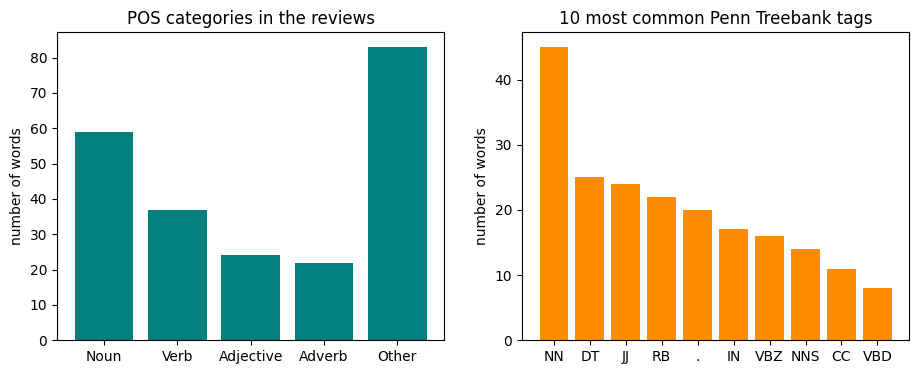

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.bar(list(counts.keys()), list(counts.values()), color='teal')
plt.ylabel("number of words")
plt.title("POS categories in the reviews")

plt.subplot(1,2,2)
tag_counts = Counter(t for w, t in all_tagged).most_common(10)
plt.bar([t for t, n in tag_counts], [n for t, n in tag_counts], color='darkorange')
plt.ylabel("number of words")
plt.title("10 most common Penn Treebank tags")

plt.show()

Counting the categories review wise also, because a review having more adjectives is usually the one which is giving a strong opinion about the product.

In [13]:
print("review   rating   nouns   verbs   adj   adv")
for i in range(len(df)):
    cats = [category(t) for w, t in df["tagged"][i]]
    print(str(i+1).rjust(5), str(df["rating"][i]).rjust(7),
          str(cats.count("Noun")).rjust(7), str(cats.count("Verb")).rjust(7),
          str(cats.count("Adjective")).rjust(6), str(cats.count("Adverb")).rjust(5))

review   rating   nouns   verbs   adj   adv
    1       5       5       2      2     2
    2       2       5       5      2     1
    3       4       5       4      3     4
    4       3       5       3      2     0
    5       5       4       2      1     4
    6       1       5       4      2     1
    7       4       6       3      1     4
    8       5       3       4      1     2
    9       2       6       5      1     0
   10       4       6       2      3     1
   11       3       5       2      2     1
   12       5       4       1      4     2


### Result
Twelve customer reviews were loaded from `reviews.csv`, cleaned and normalized, tokenized into words, and every word was given a Part of Speech tag using `nltk.pos_tag`. The tagged words were displayed in the `word/TAG` format and the number of nouns, verbs, adjectives, adverbs and other categories was counted for the whole dataset as well as for each review.

The counts are shown in the table below. The other category is the biggest one because it contains the determiners, prepositions, conjunctions and also the full stops, 20 of those 83 are only the full stops of the sentences.

| Category | Count |
|---|---|
| Noun | 59 |
| Verb | 37 |
| Adjective | 24 |
| Adverb | 22 |
| Other | 83 |
| **Total** | **225** |

### Conclusion
Tokenization and Part of Speech tagging were performed successfully on a set of customer reviews taken from an e-commerce dataset.

The experiment shows that the tag of a word is decided by the position of the word in the sentence and not only by the word itself, because the tagger uses a model trained on a tagged corpus instead of a fixed dictionary. This is the reason the same word can receive a different tag in two different reviews.

The distribution of the categories is also useful information about the dataset. Nouns are the largest group because the reviews are mostly talking about the product and its parts, and the adjectives and adverbs, although fewer in number, are the words which actually carry the opinion of the customer such as excellent, poor, comfortable and quickly. For a sentiment analysis task these two categories are the most important ones.

The tagger is not correct every single time. In the third review it tagged `fabric/JJ` and `feels/NNS` although fabric is a noun and feels is a verb, and in the second review it tagged `build/JJ` in the phrase build quality. This happens because the model decides the tag from the surrounding words, and one reason for these mistakes here is the normalization step itself, the text was converted to lower case so the tagger lost the capital letter which normally helps it to identify a noun at the beginning of a sentence.

It is concluded that POS tagging is an important preprocessing step in NLP. It is required for correct lemmatization, for extracting the features of a product from a review, and for opinion mining where the adjectives and the adverbs decide whether the review is positive or negative.